<a href="https://colab.research.google.com/github/sonalkmr/Python_Daily_Practice/blob/main/Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#https://github.com/team-codebug/babua-dsa-patterns-course

In [2]:
#Without enumerate()
fruits = ["apple", "banana", "cherry"]
index = 0

for fruit in fruits:
    print(index, fruit)
    index += 1

#With enumerate()
for index, fruit in enumerate(fruits):
    print(index, fruit)


0 apple
1 banana
2 cherry
0 apple
1 banana
2 cherry


              precision    recall  f1-score   support

           0       0.93      0.98      0.95       837
           1       0.94      0.82      0.88       363

    accuracy                           0.93      1200
   macro avg       0.93      0.90      0.91      1200
weighted avg       0.93      0.93      0.93      1200

ROC-AUC: 0.9752526898176949


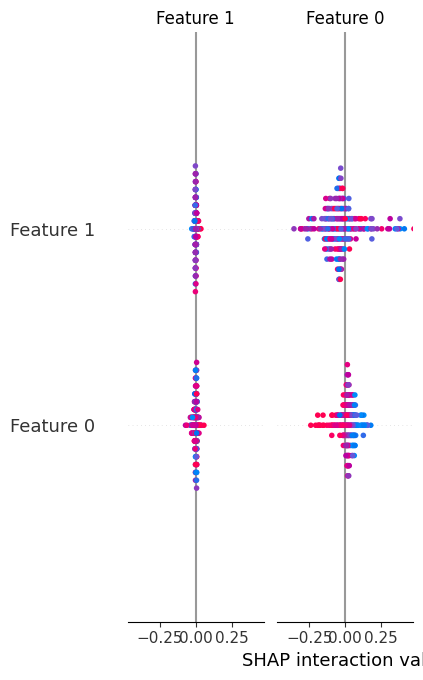

In [2]:
"""
Advanced End-to-End Machine Learning Pipeline for Data Scientists
Use Case: Customer Churn Prediction
"""

import numpy as np
import pandas as pd
import logging
from dataclasses import dataclass

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.ensemble import RandomForestClassifier

import shap
import joblib
import matplotlib.pyplot as plt

# --------------------------------------------------
# Logging Configuration
# --------------------------------------------------
logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")

# --------------------------------------------------
# Configuration Dataclass
# --------------------------------------------------
@dataclass
class Config:
    test_size: float = 0.2
    random_state: int = 42
    model_path: str = "churn_model.pkl"

# --------------------------------------------------
# Data Loader
# --------------------------------------------------
from sklearn.datasets import make_classification
import numpy as np
import pandas as pd

class DataLoader:
    def load(self, path=None):
        X, y = make_classification(
            n_samples=6000,
            n_features=8,
            n_informative=5,
            n_redundant=1,
            class_sep=1.2,
            weights=[0.7, 0.3],
            random_state=42
        )

        df = pd.DataFrame(X, columns=[
            "monthly_charges",
            "total_charges",
            "usage_minutes",
            "support_calls",
            "payment_delay",
            "complaints",
            "downloads",
            "uploads"
        ])

        # Add realistic categorical features
        df["contract_type"] = np.random.choice(
            ["Month-to-month", "One year", "Two year"], size=len(df)
        )

        df["internet_service"] = np.random.choice(
            ["DSL", "Fiber optic", "None"], size=len(df)
        )

        df["tenure"] = np.random.randint(1, 72, size=len(df))
        df["churn"] = y

        return df


# --------------------------------------------------
# Feature Engineering
# --------------------------------------------------
class FeatureEngineer:
    def transform(self, df: pd.DataFrame) -> pd.DataFrame:
        logging.info("Performing feature engineering...")
        df["tenure_group"] = pd.cut(
            df["tenure"],
            bins=[0, 12, 24, 48, 72],
            labels=["0-1yr", "1-2yr", "2-4yr", "4-6yr"]
        )
        return df

# --------------------------------------------------
# Model Pipeline
# --------------------------------------------------
class ChurnModel:
    def __init__(self, config: Config):
        self.config = config
        self.model = None

    def build_pipeline(self, X: pd.DataFrame):
        numeric_features = X.select_dtypes(include=np.number).columns
        categorical_features = X.select_dtypes(exclude=np.number).columns

        numeric_pipeline = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ])

        categorical_pipeline = Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ])

        preprocessor = ColumnTransformer([
            ("num", numeric_pipeline, numeric_features),
            ("cat", categorical_pipeline, categorical_features)
        ])

        classifier = RandomForestClassifier(random_state=self.config.random_state)

        pipeline = Pipeline([
            ("preprocessor", preprocessor),
            ("model", classifier)
        ])

        return pipeline

    def train(self, X_train, y_train):
        logging.info("Training model with hyperparameter tuning...")
        pipeline = self.build_pipeline(X_train)

        param_grid = {
            "model__n_estimators": [100, 200],
            "model__max_depth": [5, 10, None],
            "model__min_samples_split": [2, 5]
        }

        grid = GridSearchCV(
            pipeline,
            param_grid,
            cv=5,
            scoring="roc_auc",
            n_jobs=-1
        )

        grid.fit(X_train, y_train)
        self.model = grid.best_estimator_

        logging.info(f"Best Parameters: {grid.best_params_}")

    def evaluate(self, X_test, y_test):
        logging.info("Evaluating model...")
        preds = self.model.predict(X_test)
        probs = self.model.predict_proba(X_test)[:, 1]

        print(classification_report(y_test, preds))
        print("ROC-AUC:", roc_auc_score(y_test, probs))

    def explain(self, X_sample):
        logging.info("Generating SHAP explanations...")
        explainer = shap.Explainer(self.model["model"])
        shap_values = explainer(
            self.model["preprocessor"].transform(X_sample)
        )
        shap.summary_plot(shap_values, show=False)
        plt.show()

    def save(self):
        joblib.dump(self.model, self.config.model_path)
        logging.info("Model saved successfully.")

# --------------------------------------------------
# Main Execution
# --------------------------------------------------
def main():
    config = Config()

    loader = DataLoader()
    fe = FeatureEngineer()
    model = ChurnModel(config)

    df = loader.load("customer_churn.csv")
    df = fe.transform(df)

    X = df.drop("churn", axis=1)
    y = df["churn"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=config.test_size,
        random_state=config.random_state,
        stratify=y
    )

    model.train(X_train, y_train)
    model.evaluate(X_test, y_test)
    model.explain(X_test.sample(200))
    model.save()

if __name__ == "__main__":
    main()


In [ ]:
#To check Armstrong number
num = int(input("Enter a number:"))

num_str = str(num)
num_digits = len(num_str)
sum_of_powers = 0
temp_num = num
while temp_num > 0:
  digit = temp_num % 10
  sum_of_powers += digit ** num_digits
  temp_num //= 10

if sum_of_powers == num:
  print(f"{num}is an armstrong number")
else:
  print(f"{num}is not an armstrong number")



Enter a number:4
4is an armstrong number


In [ ]:
#fibonancci sequence
n = int(input("Enter number of terms: "))

a, b = 0, 1

print("Fibonacci sequence:")
for _ in range(n):
    print(a, end=" ")
    a, b = b, a + b


Enter number of terms: 9
Fibonacci sequence:
0 1 1 2 3 5 8 13 21 

In [ ]:
#Multiplication Table
num = int(input("Display multiplication table of: "))

for i in range(1,11):
  print(f"{num} X {i} = {num*i}")

Display multiplication table of: 7
7 X 1 = 7
7 X 2 = 14
7 X 3 = 21
7 X 4 = 28
7 X 5 = 35
7 X 6 = 42
7 X 7 = 49
7 X 8 = 56
7 X 9 = 63
7 X 10 = 70


In [ ]:
#Find the factorial of a number
num = int(input("Enter a number:"))
factorial = 1
if num < 0:
  print("factorial doesnt exist for nrgative numbers")
elif num == 0:
  print("factorial of 0 is 1")
else:
  for i in range (1, num+1):
    factorial = factorial*i
  print(f'The factorial of {num} is {factorial}')

Enter a number:5
The factorial of 5 is 120


In [ ]:
#prime number within an interval
l = 2
u = 10
print("prime numbers between", l, "and", u, "are:" )

for num in range (l,u):
  for i in range (2,int(num**0.5)+1):
    if num % i == 0:
      break
  else:
      print(num)


prime numbers between 2 and 10 are:
2
3
5
7


In [ ]:
#Prime number within an interval
l = 1
u = 10
print("prime numbers between", l, "and", u, "are:" )

for num in range(l, u+1):
  if num > 1:
    for i in range (2, num):
      if (num%i) == 0:
        break
    else:
        print(num)


prime numbers between 1 and 10 are:
2
3
5
7


In [ ]:
#check for prime

num = int(input("Enter a number: "))

flag = False

if num == 1:
  print(f"{num},is not a prime number")
elif num > 1:
  for i in range(2, num):
    if (num % i) == 0:
      flag = True
      break

if flag:
  print(f"{num},is not a prime number")
else:
  print(f"{num},is a prime number")

Enter a number: 8
8,is not a prime number


In [ ]:
#Number Is Odd or Even
num = int(input("Enter a number: "))
if num%2 == 0:
  print("This is a even number")
else:
  print("This is a odd number")

Enter a number: 2
This is a even number


In [ ]:
#Longest Substring Without Repeating Characters
def longest_unique_substring(s):
    char_set = set()
    left = 0
    max_length = 0

    for right in range(len(s)):
        while s[right] in char_set:
            char_set.remove(s[left])
            left += 1

        char_set.add(s[right])
        max_length = max(max_length, right - left + 1)

    return max_length


# Test cases
print(longest_unique_substring("abcabcbb"))  # 3
print(longest_unique_substring("bbbbb"))     # 1
print(longest_unique_substring("pwwkew"))    # 3

3
1
3


In [ ]:
#First Non-Repeating Character
def first_non_repeating_char(s):
    char_count = {}

    # Count frequency of each character
    for char in s:
        char_count[char] = char_count.get(char, 0) + 1

    # Find first character with count 1
    for char in s:
        if char_count[char] == 1:
            return char

    return None


# Test cases
print(first_non_repeating_char("swiss"))     # w
print(first_non_repeating_char("aabbcc"))    # None
print(first_non_repeating_char("python"))    # p


w
None
p


In [ ]:
#Q5. Write a Python program that prints the following sentence
#"Welcome to Python programming!"

print("Welcome to Python programming!")

#Q6. Print your full name by concatenating your first and last name using the + operator and proper spacing

first_name = "Sonal"
last_name = "Kumar"
print(first_name + " " + last_name)

#Q7. Print the result of the following expressions using Python
#a) 2 + 3 * 5
print(2 + 3 * 5)

#b) 10 / 2 - 3
print(10 / 2 - 3)

#Q8. Try printing a string without quotes (e.g. print(Hello)). Include the error you get and write how you corrected it
#print(Hello)
print("Hello")

#Q9. Create a Python program that concatenates the numbers "2024" and "is" as strings, then prints the result
print("2024" + "is")

#Q10. Write a code snippet that prints a sentence and a number in one line using a comma inside the print function
print("I scored", 95)

Welcome to Python programming!
Sonal Kumar
17
2.0
Hello
2024is
I scored 95


In [ ]:
#Option 1: Basic Python Code
  #Write a Python program that calculates the average of three numbers entered by the user and categorizes the result as 'Low', 'Medium', or 'High'.

num1 = float (input("Enter first number:"))
num2 = float (input("Enter first number:"))
num3 = float (input("Enter first number:"))

average = (num1 + num2 + num3)/3

if average < 40:
  category = "Low"
elif average < 70:
  category = "Medium"
else:
  category = "High"

print("Average:",average)
print("category:",)

Enter first number:12
Enter first number:13
Enter first number:12
Average: 12.333333333333334
category: Low


In [ ]:
#Option 2: AI Contextual Example
  #Create a Python dictionary to store different AI libraries and their key use cases (at least 5). Print this information in a readable format.
ai_libraries = {
    "TensorFlow": "Deep learning and neural networks",
    "PyTorch": "Research-focused deep learning and model training",
    "Scikit-learn": "Machine learning algorithms and data analysis",
    "OpenCV": "Computer vision and image processing",
    "NLTK": "Natural language processing and text analysis"
}

# Print the information in a readable format
print("AI Libraries and Their Use Cases:\n")

for library, use_case in ai_libraries.items():
    print(f"- {library}: {use_case}")

AI Libraries and Their Use Cases:

- TensorFlow: Deep learning and neural networks
- PyTorch: Research-focused deep learning and model training
- Scikit-learn: Machine learning algorithms and data analysis
- OpenCV: Computer vision and image processing
- NLTK: Natural language processing and text analysis


In [ ]:
#Pair sum in sorted Array

In [ ]:
def pair_sum(nums, target):
    left, right = 0, len(nums) - 1

    while left < right:
        curr_sum = nums[left] + nums[right]

        if curr_sum == target:
            return True   # ✅ correctly indented

        if curr_sum < target:
            left += 1
        else:
            right -= 1

    return False
    #Example
print(pair_sum([1, 2, 3, 4, 6], 7)) # True

True
